# evtools — Tutorial

**Evidence Theory Tools** — a Python library for working with belief functions in the Dempster-Shafer / Transferable Belief Model framework.

This tutorial uses a running example: a sensor classifying aerial targets as **airplane** (a), **helicopter** (h), or **rocket** (r).

**Sections**
1. Building a BBA
2. Accessing values
3. Conversions (bel, pl, b, q)
4. Conjunctive and disjunctive weights (v, w)
5. Simple MFs
6. Combination rules
7. Decombination
8. Correction mechanisms
9. Display formats
10. all_kinds — all representations in one table
11. Conditioning and deconditioning
12. Pignistic and plausibility probability transformations
13. Low-level conversions API

**References**
- P. Smets. *The application of the matrix calculus to belief functions*, IJAR, 31(1–2):1–30, 2002.
- T. Denœux. *Conjunctive and disjunctive combination of belief functions induced by nondistinct bodies of evidence*, AI, 172:234–264, 2008.
- D. Mercier, B. Quost, T. Denœux. *Refined modeling of sensor reliability in the belief function framework using contextual discounting*, Information Fusion, 9(2):246–258, 2008.
- F. Pichon, D. Mercier, É. Lefèvre, F. Delmotte. *Proposition and learning of some belief function contextual correction mechanisms*, IJAR, 72:4–42, 2016.

## Setup

In [ ]:
import numpy as np
from evtools.dsvector import DSVector, Kind
from evtools.combinations import crc, dempster, drc, cautious, bold, decombine_crc, decombine_drc
from evtools.corrections import (
    discount, contextual_discount, theta_contextual_discount,
    contextual_reinforce, contextual_dediscount, contextual_dereinforce,
    contextual_negate,
)
from evtools.display import to_string, to_html, to_latex

frame = ["a", "h", "r"]  # airplane, helicopter, rocket
print("evtools loaded successfully")

---
## 1. Building a Basic Belief Assignment (BBA)

A BBA is a function $m: 2^\Omega \to [0,1]$ with $\sum_{A \subseteq \Omega} m(A) = 1$.

**Three constructors are available:**

In [ ]:
# from_focal: human-friendly string keys.
# Missing mass is automatically assigned to Ω = {a, h, r}.
m = DSVector.from_focal(frame, {"a": 0.5, "r": 0.5})
m  # Jupyter renders the HTML table automatically via _repr_html_

In [ ]:
# from_dense: numpy array in binary index order (Smets 2002).
# Index i → subset whose members are the atoms at the bit positions set in i.
# For frame=[a,h,r]: 0=∅, 1={a}, 2={h}, 3={a,h}, 4={r}, 5={a,r}, 6={h,r}, 7={a,h,r}
array = np.array([0.0, 0.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0])
m2 = DSVector.from_dense(frame, array)
m2

In [ ]:
# from_sparse: dict of frozensets.
m3 = DSVector.from_sparse(frame, {
    frozenset({"a"}): 0.5,
    frozenset({"r"}): 0.5,
})
m3

In [ ]:
# Subnormal BBA: m(∅) > 0 (allowed in the TBM, represents internal conflict)
m_sub = DSVector.from_focal(frame, {"": 0.1, "a": 0.3, "r": 0.4, "a,h,r": 0.2}, complete=False)
print(f"is_valid: {m_sub.is_valid}")
m_sub

---
## 2. Accessing Values

In [ ]:
print("sparse dict :", m.sparse)
print("dense array :", m.dense)
print("m({a})      :", m[frozenset({"a"})])
print("m({h})      :", m[frozenset({"h"})], " ← not a focal element")
print("n_focal     :", m.n_focal)
print("is_valid    :", m.is_valid)

In [ ]:
print("Iterating over focal elements:")
for subset, value in m:
    label = "{"+", ".join(sorted(subset))+"}" if subset else "∅"
    print(f"  m({label}) = {value:.4f}")

---
## 3. Conversions

All standard representations are available via `.to(Kind)` or shortcuts.
The column header in the display adapts to the kind (`m`, `bel`, `pl`, `b`, `q`, `v`, `w`).

In [ ]:
m.to_bel()  # Belief function

In [ ]:
m.to_pl()  # Plausibility function

In [ ]:
m.to_b()  # Implicability function

In [ ]:
m.to_q()  # Commonality function

In [ ]:
# Round-trip consistency check
for kind in [Kind.BEL, Kind.PL, Kind.B, Kind.Q]:
    back = m.to(kind).to(Kind.M)
    ok = np.allclose(back.dense, m.dense, atol=1e-10)
    print(f"  m → {kind.value:>3} → m : {'✓ OK' if ok else '✗ MISMATCH'}")

---
## 4. Conjunctive and Disjunctive Weights (v, w)

The conjunctive weight function $w$ and disjunctive weight function $v$ require
a **subnormal BBA** ($m(\emptyset) > 0$), so that $b(A) > 0$ for all $A \subseteq \Omega$.

They are defined via a Möbius transform on $\ln q$ (for $w$) and $\ln b$ (for $v$),
and are essential for the **Cautious** and **Bold** combination rules (Denoeux 2008).

In [ ]:
# Subnormal BBA required: m(∅) > 0
m_sub2 = DSVector.from_focal(frame, {"": 0.1, "a": 0.3, "r": 0.4, "a,h,r": 0.2}, complete=False)
print(f"is_valid: {m_sub2.is_valid}")
m_sub2

In [ ]:
# Disjunctive weight function v
m_sub2.to_v()

In [ ]:
# Conjunctive weight function w
m_sub2.to_w()

In [ ]:
# Round-trip consistency for v and w
for kind in [Kind.V, Kind.W]:
    back = m_sub2.to(kind).to(Kind.M)
    ok = np.allclose(back.dense, m_sub2.dense, atol=1e-10)
    print(f"  m_sub → {kind.value} → m : {'✓ OK' if ok else '✗ MISMATCH'}")

---
## 5. Simple MFs

Simple MFs are the elementary building blocks of correction mechanisms:
- $A^\beta$ (`DSVector.simple`): focal sets $\Omega$ (mass $\beta$) and $A$ (mass $1-\beta$) — used in CR, CdR, CN
- $A_\beta$ (`DSVector.negative_simple`): focal sets $\emptyset$ (mass $\beta$) and $A$ (mass $1-\beta$) — used in CD, CdD

In [ ]:
# Simple MF A^β (positive)
DSVector.simple(frame, frozenset({"a"}), beta=0.6)

In [ ]:
# Negative simple MF A_β
DSVector.negative_simple(frame, frozenset({"a"}), beta=0.4)

---
## 6. Combination Rules

| | All sources reliable | At least one reliable |
|---|---|---|
| **Distinct sources** | `crc` (`&`) / `dempster` (`@`) | `drc` (`\|`) |
| **Nondistinct sources** | `cautious` | `bold` |

In [ ]:
s1 = DSVector.from_focal(frame, {"a": 0.5, "r": 0.5})
s2 = DSVector.from_focal(frame, {"h": 0.3, "r": 0.4, "a,h,r": 0.3})

# CRC — distinct, both reliable (operator &)
m12_crc = s1 & s2
print(f"Conflict m(∅) = {m12_crc[frozenset()]:.4f}")
m12_crc

In [ ]:
# Dempster's rule — normalized CRC (operator @)
s1 @ s2

In [ ]:
# DRC — at least one reliable (operator |)
s1 | s2

In [ ]:
# Cautious — nondistinct, both reliable; commutative, associative, idempotent
s1_nd = DSVector.from_focal(frame, {"a": 0.3, "h": 0.2, "a,h,r": 0.5})
s2_nd = DSVector.from_focal(frame, {"a": 0.4, "r": 0.1, "a,h,r": 0.5})
m_caut = cautious(s1_nd, s2_nd)
print(f"Idempotent: cautious(m,m)==m → {np.allclose(cautious(s1_nd,s1_nd).dense, s1_nd.dense, atol=1e-10)}")
m_caut

In [ ]:
# Bold — nondistinct, at least one reliable (requires subnormal BBAs)
b1 = DSVector.from_focal(frame, {"": 0.1, "a": 0.4, "a,h,r": 0.5}, complete=False)
b2 = DSVector.from_focal(frame, {"": 0.2, "r": 0.3, "a,h,r": 0.5}, complete=False)
bold(b1, b2)

---
## 7. Decombination

Inverse operations to remove a previously combined BBA.
The result may not be a valid BBA — always check `.is_valid`.

In [ ]:
# decombine_crc: m1 6∩ m2
m1 = DSVector.from_focal(frame, {"a": 0.4, "a,h,r": 0.6})
m2 = DSVector.from_focal(frame, {"h": 0.3, "a,h,r": 0.7})
m12 = crc(m1, m2)
m1_recovered = decombine_crc(m12, m2)

print(f"is_valid  : {m1_recovered.is_valid}")
print(f"Recovers m1: {np.allclose(m1_recovered.dense, m1.dense, atol=1e-6)}")
m1_recovered

---
## 8. Correction Mechanisms

Corrections adjust a BBA based on knowledge about the source quality (reliability, truthfulness).

| Mechanism | Notation | Source assumption |
|-----------|---------|-------------------|
| `discount(m, β)` | $m_S \cup \Omega_{\beta}$ | single reliability degree |
| `contextual_discount(m, β)` (CD) | $m_S \cup \bigcup_{A} A_{\beta_A}$ | reliability per singleton |
| `theta_contextual_discount(m, β)` | general Θ partition | reliability per coarsening |
| `contextual_reinforce(m, β)` (CR) | $m_S \cap \bigcap_{A} A^{\beta_A}$ | contextual positive liar |
| `contextual_dediscount(m, β)` (CdD) | inverse of CD | undo a prior CD |
| `contextual_dereinforce(m, β)` (CdR) | inverse of CR | undo a prior CR |
| `contextual_negate(m, β)` (CN) | equivalence rule | contextual non-truthful |

In [ ]:
m = DSVector.from_focal(frame, {"a": 0.5, "r": 0.5})

# Classical discounting: β=0.6, source 60% reliable
discount(m, beta=0.6)

In [ ]:
# Contextual discounting: sensor unreliable only when target is airplane
# β_a=0.6, β_h=1.0, β_r=1.0  (Example 1, Case 1 of Mercier et al. 2008)
betas_cd = {frozenset({"a"}): 0.6, frozenset({"h"}): 1.0, frozenset({"r"}): 1.0}
mcd = contextual_discount(m, betas_cd)
# Interpretation: mass on {r} partially transferred to {a,r}
# because if the true target is airplane, sensor may declare it a rocket
mcd

In [ ]:
# Θ-contextual discounting: coarser partition Θ = {{a}, {h,r}}
theta_contextual_discount(m, {frozenset({"a"}): 0.4, frozenset({"h","r"}): 0.9})

In [ ]:
# Contextual Reinforcement (CR) — dual of CD, uses CRC
contextual_reinforce(m, betas_cd)

In [ ]:
# CdD: inverse of CD — check .is_valid after decombination
mdd = contextual_dediscount(mcd, betas_cd)
print(f"is_valid      : {mdd.is_valid}")
print(f"CdD reverts CD: {np.allclose(mdd.dense, m.dense, atol=1e-6)}")
mdd

In [ ]:
# Contextual Negating (CN): source non-truthful with probability 1−β
contextual_negate(m, {frozenset({"a"}): 0.7})

In [ ]:
# Pure negation: β=0, A=∅  →  m(B) becomes m(B̄) for all B
contextual_negate(m, {frozenset(): 0.0})

---
## 9. Display Formats

Four output formats are available. In Jupyter, `DSVector` renders as an HTML table automatically (via `_repr_html_`). Use `.to_<fmt>()` to request a specific format.

In [ ]:
m = DSVector.from_focal(frame, {"a": 0.5, "r": 0.5})

# HTML (default in Jupyter)
m

In [ ]:
# Plain text — no colors, for logging and files
print(to_string(m))

In [ ]:
# Column header adapts to the kind
print("--- Belief function ---")
print(to_string(m.to_bel()))
print("\n--- Plausibility function ---")
print(to_string(m.to_pl()))
print("\n--- Commonality function ---")
print(to_string(m.to_q()))

In [ ]:
# LaTeX — ready to paste in a paper
print(to_latex(m))

In [ ]:
# Explicit format selection
print(m.to_string())

---
## 13. Low-level Conversions API

All conversions are available as standalone functions on numpy arrays,
using the Fast Möbius Transform (Smets 2002, Section 3).

In [ ]:
from evtools.conversions import mtob, mtopl, mtoq, mtobel

m_array = np.array([0.0, 0.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0])
print("m     :", m_array)
print("bel   :", mtobel(m_array))
print("pl    :", mtopl(m_array))
print("b     :", mtob(m_array))
print("q     :", mtoq(m_array))

---
## 10. all_kinds — All Representations in One Table

`m.to_ansi(all_kinds=True)` renders `m`, `bel`, `pl`, `b`, `q` in a single table.
Additional columns are added automatically:

- **v** (disjunctive weights): added when the BBA is **subnormal** ($m(\emptyset) > 0$),
  so that $b(A) > 0$ for all $A \subseteq \Omega$
- **w** (conjunctive weights): added when the BBA is **non-dogmatic** ($m(\Omega) > 0$),
  so that $q(A) > 0$ for all $A \subsetneq \Omega$

In [ ]:


# Normal dogmatic BBA: m(∅)=0, m(Ω)=0 → only m, bel, pl, b, q
m_dog = DSVector.from_focal(frame, {"a": 0.5, "r": 0.5})
print("Normal dogmatic BBA (no v, no w):")
print(to_string(m_dog))

In [ ]:
# Non-dogmatic BBA: m(Ω)>0 → w column added
m_nd = DSVector.from_focal(frame, {"a": 0.3, "r": 0.3, "a,h,r": 0.4})
print(f"Non-dogmatic (m(Ω)={m_nd[frozenset({'a','h','r'})]:.1f}) → w column added:")
print(m_nd.to_string(all_kinds=True))

In [ ]:
# Subnormal dogmatic: m(∅)>0, m(Ω)=0 → v column added
m_sub3 = DSVector.from_focal(frame, {"": 0.1, "a": 0.5, "r": 0.4}, complete=False)
print(f"Subnormal dogmatic (m(∅)={m_sub3[frozenset()]:.1f}) → v column added:")
print(m_sub3.to_string(all_kinds=True))

In [ ]:
# Subnormal non-dogmatic: m(∅)>0 and m(Ω)>0 → both v and w
m_full = DSVector.from_focal(frame, {"": 0.1, "a": 0.3, "r": 0.4, "a,h,r": 0.2}, complete=False)
print("Subnormal non-dogmatic → both v and w:")
print(m_full.to_string(all_kinds=True))

In [ ]:
# In Jupyter: all_kinds renders as HTML
from IPython.display import HTML
HTML(m_nd.to_html(all_kinds=True))

In [ ]:
# LaTeX output — ready to paste in a paper
print(m_nd.to_latex(all_kinds=True))

---
## 11. Conditioning and Deconditioning

**Conditioning** on $A$ gives the least committed **specialization** of $m$
such that $pl(\bar{A}) = 0$ (Smets 2002, Section 9):

$$m[A](B) = \sum_{C\,:\,C\cap A = B} m(C), \quad \forall B \subseteq A$$

**Deconditioning** is the inverse: the least committed **generalization** $m^*$
such that $pl^*(\bar{A}) = 1$:

$$m^*(B \cup \bar{A}) = m(B), \quad \forall B \subseteq A$$

Both are available in `sparse` (default) and `dense` modes via the
matrices $C_A$ and $D_A$ (`conversions.conditioning_matrix` / `deconditioning_matrix`).

In [ ]:
from evtools.combinations import condition, decondition
from evtools.conversions import conditioning_matrix, deconditioning_matrix

m_base = DSVector.from_focal(frame, {"a": 0.3, "h": 0.2, "a,h": 0.1, "a,h,r": 0.4})
A = frozenset({"a", "h"})
print("Original BBA:")
m_base

In [ ]:
# Conditioning on A = {a, h}
m_cond = condition(m_base, A)
print("m conditioned on A = {a, h}:")
m_cond

In [ ]:
# Deconditioning: B → B ∪ Ā = B ∪ {r}
m_decond = decondition(m_cond, A)
print("Deconditioned BBA (B → B ∪ {r}):")
m_decond

In [ ]:
# Round-trip: condition(decondition(m[A], A), A) == m[A]
ok = np.allclose(condition(m_decond, A).dense, m_cond.dense, atol=1e-10)
print(f"condition(decondition(m[A], A), A) == m[A] : {ok}")

# Sparse vs dense
ok2 = np.allclose(
    condition(m_base, A, method='sparse').dense,
    condition(m_base, A, method='dense').dense, atol=1e-10)
print(f"sparse == dense : {ok2}")

In [ ]:
# Conditioning matrix C_A — specialization matrix (column sums = 1)
CA = conditioning_matrix(frame, A)
print(f"C_A shape: {CA.shape}")
print(f"Column sums = 1: {np.allclose(CA.sum(axis=0), 1.0)}")
print(f"C_A @ m == condition(m, A): {np.allclose(CA @ m_base.dense, m_cond.dense, atol=1e-10)}")

In [ ]:
# Deconditioning matrix D_A — generalization matrix (column sums = 1)
DA = deconditioning_matrix(frame, A)
print(f"D_A shape: {DA.shape}")
print(f"Column sums = 1: {np.allclose(DA.sum(axis=0), 1.0)}")
print(f"D_A @ m_cond == decondition(m_cond, A): {np.allclose(DA @ m_cond.dense, m_decond.dense, atol=1e-10)}")

---
## 13. Pignistic and Plausibility Probability Transformations

Both transformations map a BBA to a **probability vector of length $n$**
(one value per atom), used for decision-making in the TBM.

$$\mathrm{BetP}(\{x\}) = \sum_{A \ni x} \frac{m(A)}{|A| \cdot (1 - m(\emptyset))}$$

$$\mathrm{PlP}(\{x\}) = \frac{pl(\{x\})}{\sum_{y \in \Omega} pl(\{y\})}$$

The result is a `numpy.ndarray` of length $n$, **not** a `DSVector`.

In [ ]:
from evtools.conversions import betp, plp

m_demo = DSVector.from_focal(frame, {"a": 0.3, "a,h": 0.4, "a,h,r": 0.3})
m_demo

In [ ]:
# BetP — pignistic transformation
bp = m_demo.to_betp()
print("BetP:")
for atom, val in zip(frame, bp):
    print(f"  BetP({{{atom}}}) = {val:.4f}")
print(f"Sum = {bp.sum():.4f}")
print(f"type: {type(bp)}, length: {len(bp)}  ← n atoms, not 2^n")

In [ ]:
# PlP — plausibility probability
pp = m_demo.to_plp()
print("PlP:")
for atom, val in zip(frame, pp):
    print(f"  PlP({{{atom}}}) = {val:.4f}")
print(f"Sum = {pp.sum():.4f}")

In [ ]:
# Special cases
m_vac = DSVector.from_focal(frame, {})
m_cat = DSVector.from_focal(frame, {"a": 1.0})
print(f"Vacuous BBA → BetP = {m_vac.to_betp().round(4)} (uniform)")
print(f"Categorical m({{a}})=1 → BetP = {m_cat.to_betp().round(4)}")

# BetP undefined for fully contradictory BBA
import numpy as np
m_conflict = DSVector.from_sparse(frame, {frozenset(): 1.0})
try:
    m_conflict.to_betp()
except ValueError as e:
    print(f"Conflict BBA raises: {e}")

---
## 14. Decision criteria

`evtools.decision` provides two families of decision criteria:

- **Complete preference relations** — return the optimal act as `(index, atom)`:
  - `maximin(m, U)` — pessimistic: max lower expected utility
  - `maximax(m, U)` — optimistic: max upper expected utility
  - `pignistic_decision(m, U)` — MEU with BetP (Smets pignistic)
  - `plp_decision(m, U)` — MEU with PlP (Cobb & Shenoy 2006)
  - `probability_decision(m, U, transform=...)` — generic MEU under any m → probability transform (default = `plp`)
  - `hurwicz(m, U, alpha)` — convex combination of maximin and maximax

- **Partial preference relations** — return a `frozenset` of non-dominated atoms:
  - `strong_dominance(m)` — $\omega \succ \omega' \iff Bel(\{\omega\}) \geq Pl(\{\omega'\})$
  - `weak_dominance(m)` — $\omega \succ \omega' \iff Bel(\{\omega\}) \geq Bel(\{\omega'\})$ and $Pl(\{\omega\}) \geq Pl(\{\omega'\})$

The utility matrix $U$ has shape $(n, n)$ with $U[i, j] = u(a_i, \omega_j)$. Default = identity (0-1 utilities).


In [ ]:
from evtools.decision import (
    maximin, maximax, pignistic_decision, plp_decision, probability_decision,
    hurwicz, strong_dominance, weak_dominance,
)
from evtools.conversions import betp, plp

m_dec = DSVector.from_focal(frame, {"a": 0.3, "a,h": 0.4, "a,h,r": 0.3})
m_dec


In [ ]:
# Complete preference relations with default (identity) utility
print(f"maximin              = {maximin(m_dec)}")
print(f"maximax              = {maximax(m_dec)}")
print(f"pignistic_decision   = {pignistic_decision(m_dec)}")
print(f"plp_decision         = {plp_decision(m_dec)}")
print(f"hurwicz(α=0.5)       = {hurwicz(m_dec)}")
print(f"hurwicz(α=1.0)       = {hurwicz(m_dec, alpha=1.0)}  # ≡ maximin")
print(f"hurwicz(α=0.0)       = {hurwicz(m_dec, alpha=0.0)}  # ≡ maximax")


In [ ]:
# Generic MEU: pass the m → probability transform explicitly
print(f"transform=plp  (default) → {probability_decision(m_dec, transform=plp)}")
print(f"transform=betp           → {probability_decision(m_dec, transform=betp)}")

# Bring your own transform (e.g. uniform — ignores m, picks index 0)
import numpy as np
uniform = lambda dense: np.full(len(frame), 1.0 / len(frame))
print(f"transform=uniform        → {probability_decision(m_dec, transform=uniform)}")


In [ ]:
# Custom utility matrix — favor h heavily
U = np.array([[1.0, 0.0, 0.0],
              [0.0, 2.0, 0.0],
              [0.0, 0.0, 3.0]])
print(f"pignistic_decision(m, U) = {pignistic_decision(m_dec, U)}")
print(f"maximin(m, U)            = {maximin(m_dec, U)}")
print(f"maximax(m, U)            = {maximax(m_dec, U)}")


In [ ]:
# Partial preference relations: non-dominated atoms
print(f"strong_dominance(m) = {set(strong_dominance(m_dec))}")
print(f"weak_dominance(m)   = {set(weak_dominance(m_dec))}")


In [ ]:
# Edge cases
m_cat_dec = DSVector.from_focal(frame, {"a": 1.0})
m_vac_dec = DSVector.from_focal(frame, {})
print(f"Categorical {{a}} → pignistic = {pignistic_decision(m_cat_dec)}, "
      f"strong_dom = {set(strong_dominance(m_cat_dec))}")
print(f"Vacuous     → pignistic = {pignistic_decision(m_vac_dec)} (uniform tie-break), "
      f"strong_dom = {set(strong_dominance(m_vac_dec))}")


---
## 15. Performance metrics — `evtools.metrics`

`evtools.metrics` contains evaluation metrics for evidential predictions:

- **Set-valued predictions** (Zaffalon et al. 2012):
  - `discounted_accuracy(d, ω)` — $x = I(\omega \in d)/|d|$
  - `u65(d, ω) = 1.6x - 0.6x^2`
  - `u80(d, ω) = 2.2x - 1.2x^2`
  - `utility_score(d, ω, a=…, b=…)` — generic $a x - b x^2$

- **BBA-valued predictions** (Mercier et al. 2008, Mutmainah 2021):
  - `pl_loss(predictions, labels)` — $\sum_i \sum_k (pl_i(\omega_k) - \delta_{i,k})^2$. Same formula for hard ($E_{pl}$) and soft ($\tilde{E}_{pl}$) labels.
  - `mean_pl_loss(predictions, labels)` — `pl_loss / n`

- **Batch aggregators**: `mean_discounted_accuracy`, `mean_u65`, `mean_u80`, `mean_utility_score`.

- **Hard-classification metrics** (ROC/AUC/accuracy on precise predictions): use `sklearn.metrics` on a probability vector extracted from each BBA via `m.to_betp()` or `m.to_plp()`.

The building block `m.contour()` returns the length-$K$ vector of singleton plausibilities — used internally by `pl_loss`, `strong_dominance`, and `weak_dominance`.


In [ ]:
from evtools.metrics import (
    discounted_accuracy, u65, u80, utility_score,
    mean_discounted_accuracy, mean_u65, mean_u80,
)

true_label = "a"
for d in [frozenset({"a"}), frozenset({"a", "h"}), frozenset({"a", "h", "r"}), frozenset({"r"})]:
    label = str(set(d)) if d else "∅"
    x = discounted_accuracy(d, true_label)
    print(f"d = {label:<22}  x={x:.4f}  u65={u65(d, true_label):.4f}  u80={u80(d, true_label):.4f}")


In [ ]:
# Mean over a paired (predictions, labels) iterable
preds  = [frozenset({"a"}),  frozenset({"a", "h"}), frozenset({"r"})]
labels = ["a",               "a",                    "a"]
print(f"mean_discounted_accuracy = {mean_discounted_accuracy(preds, labels):.4f}")
print(f"mean_u65                 = {mean_u65(preds, labels):.4f}")
print(f"mean_u80                 = {mean_u80(preds, labels):.4f}")


In [ ]:
from evtools.metrics import pl_loss, mean_pl_loss

m_pred1 = DSVector.from_focal(frame, {"a": 0.6, "h": 0.2, "r": 0.2})
m_pred2 = DSVector.from_focal(frame, {"a": 0.5, "h": 0.5})
m_soft  = DSVector.from_focal(frame, {"a": 0.5, "h": 0.5})  # soft label uncertain a vs h

print(f"pl_loss (hard labels)              = {pl_loss([m_pred1, m_pred2], ['a', 'h']):.4f}")
print(f"pl_loss (soft labels)              = {pl_loss([m_pred1, m_pred2], [m_soft, m_soft]):.4f}")
print(f"pl_loss (mixed: 'a' + m_soft)      = {pl_loss([m_pred1, m_pred2], ['a', m_soft]):.4f}")
print(f"mean_pl_loss (hard, n=2)           = {mean_pl_loss([m_pred1, m_pred2], ['a', 'h']):.4f}")

# Building block: contour function (singleton plausibilities)
print(f"m_pred1.contour() = {m_pred1.contour()}")


In [ ]:
# Hard-classification metrics via scikit-learn:
# extract a probability vector (BetP or PlP) from each BBA, then feed to sklearn.
try:
    from sklearn.metrics import accuracy_score, roc_auc_score
    import numpy as np

    # Two BBAs as classifier outputs (true class is 'a' for both)
    m_a = DSVector.from_focal(frame, {"a": 0.7, "a,h": 0.3})
    m_b = DSVector.from_focal(frame, {"a": 0.4, "h": 0.5, "a,h,r": 0.1})
    bba_outputs = [m_a, m_b]
    y_true = ["a", "a"]

    # Hard prediction = argmax BetP
    y_pred = [m.frame[int(np.argmax(m.to_betp()))] for m in bba_outputs]
    print(f"y_pred = {y_pred}, y_true = {y_true}")
    print(f"accuracy_score = {accuracy_score(y_true, y_pred):.4f}")

    # Binary AUC on score = BetP({a})
    score_a = [m.to_betp()[0] for m in bba_outputs]
    y_bin   = [1 if y == "a" else 0 for y in y_true]
    if len(set(y_bin)) == 2:
        print(f"roc_auc_score  = {roc_auc_score(y_bin, score_a):.4f}")
    else:
        print("(roc_auc_score skipped: only one class in y_true; illustrative dataset)")
except ImportError:
    print("(install scikit-learn: `pip install scikit-learn`)")


---
## 16. Learning contextual correction parameters — `evtools.learning`

Closed-form least-squares fits of $\beta$ minimizing `pl_loss` (Pichon et al. 2016, Propositions 12, 14, 16):

| Correction | Closed form for $\beta_k$ |
|---|---|
| CD | $\sum_i (1 - pl_i)(1 - \delta_i) / \sum_i (1 - pl_i)^2$ |
| CR | $\sum_i pl_i \cdot \delta_i / \sum_i pl_i^2$ |
| CN | $\sum_i (2 pl_i - 1)(pl_i + \delta_i - 1) / \sum_i (2 pl_i - 1)^2$ |

All three parameters are clipped to $[0, 1]$ and the K parameters decouple per atom.

Returned dicts are ready to pass to `contextual_discount`, `contextual_reinforce`, `contextual_negate` in `evtools.corrections`. Hard labels (str) and soft labels (`DSVector`) are both supported, mixable.

**Validation**: Pichon 2016 Table 4 (data) + Table 6 (expected $\beta$ and $E_{pl}$) is reproduced numerically.

**Soft-label synthesis** — when only hard labels are available, `hard_to_soft_labels` (Mutmainah 2021, Algorithm 2; based on Côme et al. 2009 and Quost et al. 2017) draws synthetic soft labels via a Beta/Bernoulli scheme. The output is directly usable as input to `fit_*` and `pl_loss`.


In [ ]:
from evtools.learning import fit_cd, fit_cr, fit_cn
from evtools.corrections import contextual_discount, contextual_reinforce, contextual_negate
from evtools.metrics import pl_loss

# Pichon 2016 Table 4 — Sensor 1
sensor1 = [
    DSVector.from_focal(frame, {"r": 0.5, "h,r": 0.3, "a,h,r": 0.2}),  # truth = a
    DSVector.from_focal(frame, {"h": 0.5, "r": 0.2, "a,h,r": 0.3}),    # truth = h
    DSVector.from_focal(frame, {"h": 0.4, "a,r": 0.6}),                # truth = a
    DSVector.from_focal(frame, {"a,r": 0.6, "h,r": 0.4}),              # truth = r
]
truth1 = ["a", "h", "a", "r"]
print(f"baseline pl_loss = {pl_loss(sensor1, truth1):.4f}")


In [ ]:
# Fit each correction, apply it, and measure pl_loss
for name, fit_fn, apply_fn in [
    ("CD", fit_cd, contextual_discount),
    ("CR", fit_cr, contextual_reinforce),
    ("CN", fit_cn, contextual_negate),
]:
    betas = fit_fn(sensor1, truth1)
    corrected = [apply_fn(m, betas) for m in sensor1]
    loss = pl_loss(corrected, truth1)
    if name == "CD":
        bs = tuple(betas[frozenset({a})] for a in frame)
    else:
        omega = frozenset(frame)
        bs = tuple(betas[omega - {a}] for a in frame)
    print(f"{name}:  β = ({bs[0]:.2f}, {bs[1]:.2f}, {bs[2]:.2f})   pl_loss = {loss:.4f}")
# Pichon 2016 Table 6 expects:  CD pl_loss=3.39, CR pl_loss=2.33, CN pl_loss=2.59


In [ ]:
# Soft labels (Mutmainah 2021, Section 5.2 — Ẽ_pl)
soft_labels = [DSVector.from_focal(frame, {y: 1.0}) for y in truth1]
betas_soft = fit_cd(sensor1, soft_labels)
betas_hard = fit_cd(sensor1, truth1)
print("hard labels β (sorted):", sorted(round(v, 4) for v in betas_hard.values()))
print("soft labels β (sorted):", sorted(round(v, 4) for v in betas_soft.values()))


In [ ]:
# Synthesizing soft labels from hard ones (Mutmainah 2021, Algorithm 2;
# based on Côme et al. 2009 and Quost et al. 2017)
from evtools.learning import hard_to_soft_labels
import numpy as np

rng = np.random.default_rng(seed=42)
synthetic_soft = hard_to_soft_labels(truth1, frame, mu=0.5, var=0.04, rng=rng)
for hard, sft in zip(truth1, synthetic_soft):
    print(f"hard {hard!r} → soft contour = {sft.contour().round(3)}")

# These DSVector soft labels can be passed directly to fit_cd / fit_cr / fit_cn / pl_loss
betas_synth = fit_cd(sensor1, synthetic_soft)
print("\nβ from synthesized soft labels:",
      tuple(round(betas_synth[frozenset({a})], 3) for a in frame))


---
## 17. Per-group learning of contextual corrections

`fit_per_group` and `apply_per_group` implement **Algorithm 1 of Mutmainah (2021)** — Chapter 4 with hard labels and Section 5.3 with soft labels share the same code path (the lower-level `pl_loss` and `fit_*` are polymorphic in the label type).

**Procedure**: source outputs in the training set are partitioned by their partial decision (strong or weak dominance); the best of CD/CR/CN is fitted on each group. A fallback correction is also learnt on the whole training set, used at predict time when an unseen partial decision occurs.


In [ ]:
from evtools.learning import fit_per_group, apply_per_group
from evtools.decision  import strong_dominance, weak_dominance
from evtools.metrics   import pl_loss

# Reuse Pichon 2016 Sensor 1 dataset (defined in the previous section)
model = fit_per_group(sensor1, truth1, dominance=strong_dominance)
for d, gc in model.groups.items():
    label = '{' + ', '.join(sorted(d)) + '}' if d else '∅'
    print(f'group {label:<12} → kind={gc.kind!r:<5} loss={gc.loss:.4f}')
print(f'fallback        → kind={model.fallback.kind!r:<5} loss={model.fallback.loss:.4f}')


In [ ]:
# Per-group correction beats single-global on Sensor 1
corrected = apply_per_group(model, sensor1)
print(f"pl_loss baseline   : {pl_loss(sensor1, truth1):.4f}")
print(f"pl_loss global CR  : {model.fallback.loss:.4f}  (best single correction)")
print(f"pl_loss per-group  : {pl_loss(corrected, truth1):.4f}  ← best")


In [ ]:
# Same API with soft labels (Section 5.3 of the thesis)
import numpy as np
rng = np.random.default_rng(seed=2026)
soft_train = hard_to_soft_labels(truth1, frame, rng=rng)
model_soft = fit_per_group(sensor1, soft_train, dominance=strong_dominance)
corrected_soft = apply_per_group(model_soft, sensor1)
print(f'Ẽ_pl per-group (soft labels) = {pl_loss(corrected_soft, soft_train):.4f}')


---
## 18. EkNN classifier with K-fold cross-validation

`evtools.classifiers.EkNN` implements the evidence-theoretic k-NN rule of Denoeux 1995, with optional parameter optimization (Zouhal & Denoeux 1998). The cost minimized during optimization is the **Pl-loss** by default ($\lambda=1$).

We evaluate EkNN on **two built-in sklearn datasets** (Iris and Wine), with both **K-fold** (random splits) and **Stratified K-fold** (class proportions preserved). For Wine we additionally show the impact of **feature standardization** — EkNN uses Euclidean distance, so features on very different scales (alcohol, magnesium, …) hurt performance unless normalized.

Two metrics are reported:
- **accuracy** — fraction of correctly classified instances;
- **mean_pl_loss** — averaged $\sum_k (pl(\omega_k) - \delta_{i,k})^2$ over the test set.


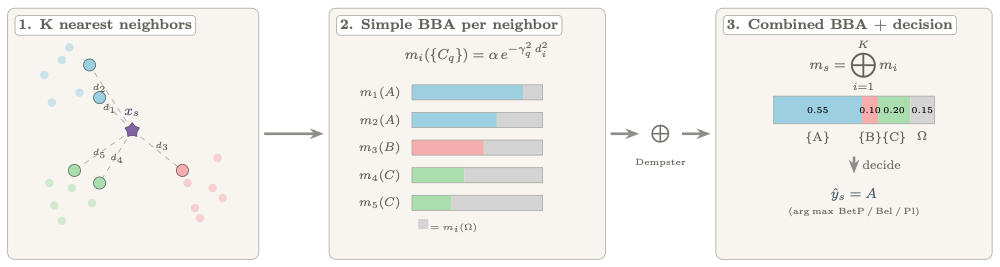

*Pipeline of the evidential k-NN classifier (Denoeux 1995, Zouhal & Denoeux 1998): (1) the K nearest neighbors of a query $x_s$ are retrieved in feature space; (2) each neighbor produces a simple BBA $m_i(\{C_q\}) = \alpha\, e^{-\gamma_q^2 d_i^2}$, $m_i(\Omega) = 1 - m_i(\{C_q\})$, where $q$ is the neighbor's class; (3) the K BBAs are combined by Dempster's rule and a decision is made via argmax of BetP, Bel, or Pl.*


In [ ]:
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from evtools.classifiers import EkNN
from evtools.metrics import mean_pl_loss
import numpy as np

def kfold_eval(X, y, splitter, k=5, optimize=True):
    accs, plloss = [], []
    split_args = (X, y) if isinstance(splitter, StratifiedKFold) else (X,)
    for tr_idx, te_idx in splitter.split(*split_args):
        clf = EkNN(k=k, optimize=optimize).fit(X[tr_idx], y[tr_idx])
        accs.append((clf.predict(X[te_idx]) == y[te_idx]).mean())
        bbas = clf.predict_bba(X[te_idx])
        plloss.append(mean_pl_loss(bbas, [str(c) for c in y[te_idx]]))
    return np.mean(accs), np.std(accs), np.mean(plloss), np.std(plloss)

DATASETS = [("Iris", load_iris(return_X_y=True)),
            ("Wine", load_wine(return_X_y=True))]

for name, (X, y) in DATASETS:
    print(f"=== {name}: n={len(X)}, d={X.shape[1]}, M={len(set(y))} ===")
    skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    a, sa, pl, spl = kfold_eval(X, y, skfold, optimize=True)
    print(f"  Stratified +optim, raw         : accuracy={a:.4f} ± {sa:.4f}, mean_pl_loss={pl:.4f}")
    X_std = StandardScaler().fit_transform(X)
    a, sa, pl, spl = kfold_eval(X_std, y, skfold, optimize=True)
    print(f"  Stratified +optim, standardized: accuracy={a:.4f} ± {sa:.4f}, mean_pl_loss={pl:.4f}")
    print()


---
## 19. EkNN on UCI benchmarks — Sonar and Ionosphere

Sonar and Ionosphere are the standard binary-classification UCI datasets used in **Zouhal & Denoeux 1998** (Figs 7-8 for Ionosphere, 11-12 for Sonar; Table II for the best-k results) to evaluate EkNN. We load them via OpenML and evaluate EkNN with 5-fold Stratified CV.

**Published reference** (Zouhal 1998, Table II, ETO = optimized γ, error = 1 − accuracy):
- Sonar       : ETO best ≈ **0.13** error → ≈ 0.87 accuracy
- Ionosphere  : ETO best ≈ **0.08** error → ≈ 0.92 accuracy

Caveats: published numbers use a fixed train/test split (not 5-fold CV), Euclidean distance, and the exact gradient-descent optimizer of the paper. Our protocol with default settings gives a slightly different estimate.


In [ ]:
from sklearn.datasets import fetch_openml

def evaluate_eknn(X, y, k=5, n_splits=5, seed=42):
    """5-fold Stratified CV with EkNN. Returns (accuracy, mean_pl_loss) means±stds."""
    skfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, plloss = [], []
    for tr_idx, te_idx in skfold.split(X, y):
        clf = EkNN(k=k, optimize=True).fit(X[tr_idx], y[tr_idx])
        accs.append((clf.predict(X[te_idx]) == y[te_idx]).mean())
        bbas = clf.predict_bba(X[te_idx])
        plloss.append(mean_pl_loss(bbas, [str(c) for c in y[te_idx]]))
    return (np.mean(accs), np.std(accs)), (np.mean(plloss), np.std(plloss))

for name, openml_id in [("Sonar", 40), ("Ionosphere", 59)]:
    try:
        data = fetch_openml(data_id=openml_id, as_frame=False, parser="liac-arff",
                            delay=2.0, n_retries=5)
        X = np.asarray(data.data, dtype=float)
        y = np.asarray(data.target)
        (acc_m, acc_s), (pl_m, pl_s) = evaluate_eknn(X, y)
        print(f"{name:<12} n={len(X):>3} d={X.shape[1]:>2}  "
              f"accuracy={acc_m:.4f} ± {acc_s:.4f}  "
              f"mean_pl_loss={pl_m:.4f} ± {pl_s:.4f}")
    except Exception as e:
        print(f"{name:<12} skipped (could not load: {type(e).__name__})")
        print(f"             → check internet, or pre-cache: "
              f"fetch_openml(data_id={openml_id})")


---
## 20. EkNN + learned correction (CD / CR / CN)

**Three-way split protocol** to test contextual corrections on a learned classifier:
1. **L1** (50%): train the EkNN classifier.
2. **L2** (25%): fit each contextual correction (CD, CR, CN) on the EkNN's BBA outputs; pick the one with lowest `mean_pl_loss` on L2.
3. **Test** (25%): apply the chosen correction on the held-out test set; compare `mean_pl_loss` before vs after.

L1 and L2 must be **disjoint** — otherwise the correction overfits the classifier's training noise rather than capturing a generalizable bias.

We use Wine **raw** (no scaling) so the EkNN baseline is imperfect (~0.72 accuracy), giving the corrections something to learn. The protocol is repeated over 10 random seeds for stability.


In [ ]:
from sklearn.datasets       import load_wine
from sklearn.model_selection import train_test_split
from evtools.classifiers    import EkNN
from evtools.learning       import fit_cd, fit_cr, fit_cn
from evtools.corrections    import contextual_discount, contextual_reinforce, contextual_negate
from evtools.metrics        import mean_pl_loss
from collections            import Counter
import numpy as np

candidates = [("CD", fit_cd, contextual_discount),
              ("CR", fit_cr, contextual_reinforce),
              ("CN", fit_cn, contextual_negate)]

X_w, y_w = load_wine(return_X_y=True)
seeds = list(range(10))
losses_before, losses_after, picks = [], [], []

for seed in seeds:
    X_L1, X_rest, y_L1, y_rest = train_test_split(X_w, y_w, test_size=0.5, stratify=y_w, random_state=seed)
    X_L2, X_test, y_L2, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=seed)

    clf = EkNN(k=5, optimize=True).fit(X_L1, y_L1)

    # Pick best correction on L2 (selection-set)
    bbas_L2 = clf.predict_bba(X_L2)
    labels_L2 = [str(c) for c in y_L2]
    best = None
    for name, fit_fn, apply_fn in candidates:
        betas = fit_fn(bbas_L2, labels_L2)
        loss  = mean_pl_loss([apply_fn(m, betas) for m in bbas_L2], labels_L2)
        if best is None or loss < best[3]:
            best = (name, betas, apply_fn, loss)
    picks.append(best[0])

    # Evaluate on test
    bbas_test = clf.predict_bba(X_test)
    labels_test = [str(c) for c in y_test]
    losses_before.append(mean_pl_loss(bbas_test, labels_test))
    losses_after.append(mean_pl_loss([best[2](m, best[1]) for m in bbas_test], labels_test))

delta = np.array(losses_before) - np.array(losses_after)
n_pos = int(np.sum(delta > 0))

print(f"Mean test mean_pl_loss BEFORE: {np.mean(losses_before):.4f} ± {np.std(losses_before):.4f}")
print(f"Mean test mean_pl_loss AFTER : {np.mean(losses_after):.4f} ± {np.std(losses_after):.4f}")
print(f"Mean Δ (before − after)      : {np.mean(delta):+.4f}  (improvement in {n_pos}/{len(seeds)} runs)")
print(f"Best correction picked       : {dict(Counter(picks))}")


---
## 21. EkNN + per-group correction (Mutmainah 2021, Algorithm 1)

Same three-way protocol as Section 20, but L2 is used to fit a **per-group correction** via `fit_per_group`. Instances are partitioned by their partial decision (strong or weak dominance), and the best of CD/CR/CN is chosen for each group separately. A fallback global correction handles unseen partial decisions at predict time.

We compare four approaches over 10 seeds:
- **No correction** (EkNN only, baseline)
- **Single best** correction on L2 (Section 20 protocol)
- **Per-group with strong dominance** ($\omega \succ \omega' \iff Bel(\omega) \geq Pl(\omega')$)
- **Per-group with weak dominance** ($\omega \succ \omega' \iff Bel(\omega) \geq Bel(\omega')$ and $Pl(\omega) \geq Pl(\omega')$)


In [ ]:
from evtools.decision import strong_dominance, weak_dominance
from evtools.learning import fit_per_group, apply_per_group

candidates = [("CD", fit_cd, contextual_discount),
              ("CR", fit_cr, contextual_reinforce),
              ("CN", fit_cn, contextual_negate)]

X_w, y_w = load_wine(return_X_y=True)
seeds = list(range(10))
losses_no, losses_glob, losses_sd, losses_wd = [], [], [], []

for seed in seeds:
    X_L1, X_rest, y_L1, y_rest = train_test_split(X_w, y_w, test_size=0.5, stratify=y_w, random_state=seed)
    X_L2, X_test, y_L2, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=seed)

    clf = EkNN(k=5, optimize=True).fit(X_L1, y_L1)
    bbas_L2   = clf.predict_bba(X_L2)
    labels_L2 = [str(c) for c in y_L2]
    bbas_test = clf.predict_bba(X_test)
    labels_test = [str(c) for c in y_test]

    losses_no.append(mean_pl_loss(bbas_test, labels_test))

    # Single best on L2
    best = None
    for name, fit_fn, apply_fn in candidates:
        betas = fit_fn(bbas_L2, labels_L2)
        loss  = mean_pl_loss([apply_fn(m, betas) for m in bbas_L2], labels_L2)
        if best is None or loss < best[3]:
            best = (name, betas, apply_fn, loss)
    losses_glob.append(mean_pl_loss([best[2](m, best[1]) for m in bbas_test], labels_test))

    # Per-group SD / WD
    model_sd = fit_per_group(bbas_L2, labels_L2, dominance=strong_dominance)
    losses_sd.append(mean_pl_loss(apply_per_group(model_sd, bbas_test), labels_test))
    model_wd = fit_per_group(bbas_L2, labels_L2, dominance=weak_dominance)
    losses_wd.append(mean_pl_loss(apply_per_group(model_wd, bbas_test), labels_test))

losses_no, losses_glob, losses_sd, losses_wd = map(np.array, (losses_no, losses_glob, losses_sd, losses_wd))

def fmt(arr, ref=None):
    s = f"{arr.mean():.4f} ± {arr.std():.4f}"
    if ref is not None:
        n = int(np.sum(ref - arr > 0))
        s += f"   ({n}/{len(arr)} better)"
    return s

print(f"No correction       : {fmt(losses_no)}")
print(f"Single best (Sec.20): {fmt(losses_glob, losses_no)}")
print(f"Per-group (SD)      : {fmt(losses_sd, losses_no)}")
print(f"Per-group (WD)      : {fmt(losses_wd, losses_no)}")


---
## Summary

| Module | Key objects / functions |
|--------|------------------------|
| `evtools.dsvector` | `DSVector`, `Kind`, `.simple()`, `.negative_simple()`, `.is_valid`, `.to_<fmt>()` |
| `evtools.combinations` | `crc` (`&`), `dempster` (`@`), `drc` (`\|`), `cautious`, `bold`, `decombine_crc`, `decombine_drc`, `condition`, `decondition` |
| `evtools.corrections` | `discount`, `contextual_discount`, `theta_contextual_discount`, `contextual_reinforce`, `contextual_dediscount`, `contextual_dereinforce`, `contextual_negate` |
| `evtools.decision` | `maximin`, `maximax`, `pignistic_decision`, `plp_decision`, `probability_decision`, `hurwicz`, `strong_dominance`, `weak_dominance` |
| `evtools.metrics` | `discounted_accuracy`, `u65`, `u80`, `utility_score` + `mean_*` aggregators, `pl_loss`/`mean_pl_loss` (E_pl/Ẽ_pl) |
| `evtools.learning` | `fit_cd`, `fit_cr`, `fit_cn` (closed-form least-squares fit of β minimizing pl_loss); `hard_to_soft_labels` (synthesizes soft labels); `fit_per_group`/`apply_per_group` (per-group correction, Mutmainah 2021 Alg. 1) |
| `evtools.classifiers` | `EkNN` (Denoeux 1995, Zouhal 1998 — sklearn-style fit/predict) |
| `evtools.display` | `to_ansi`, `to_string`, `to_html`, `to_latex` |
| `evtools.conversions` | `mtob`, `mtopl`, `mtoq`, `btom`, ... + `conditioning_matrix`, `deconditioning_matrix`, `betp`, `plp` |
| `evtools.constants` | `ZERO_MASS`, `MASS_TOL`, `VALID_TOL`, `DISPLAY_TOL` |